           DTMF DSP ANALYZER

Entered Number : 5
Decoded Number : 5

Detected Frequencies:
------------------------------------------
Digit 1: 770 Hz + 1336 Hz → 5


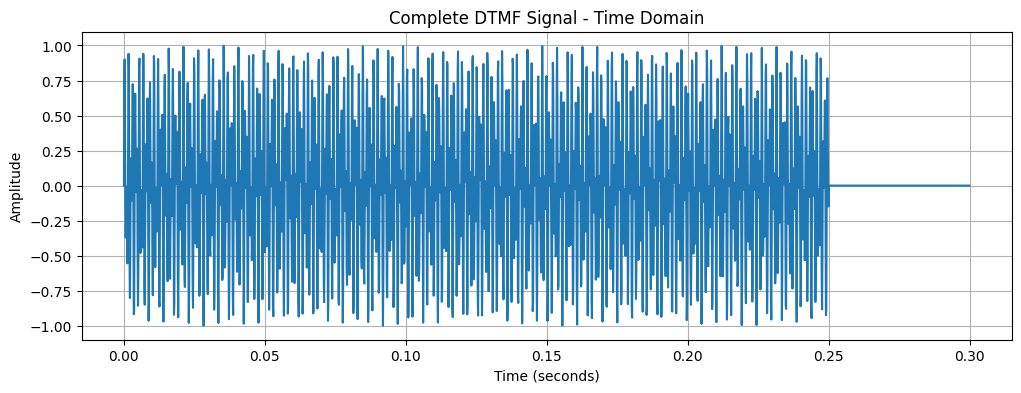

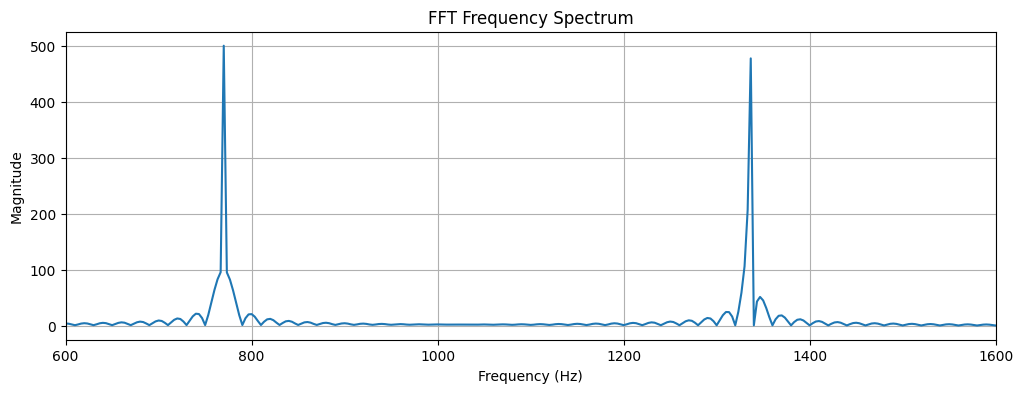


🔊 DTMF Signal:


In [ ]:
# ============================================================
# DTMF VIRTUAL KEYPAD + COMPLETE NUMBER DECODER
# DSP MICROPROJECT USING PYTHON
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Audio, clear_output

# ------------------------------------------------------------
# DTMF FREQUENCY TABLE
# ------------------------------------------------------------

DTMF = {
    '1': (697, 1209), '2': (697, 1336), '3': (697, 1477),
    '4': (770, 1209), '5': (770, 1336), '6': (770, 1477),
    '7': (852, 1209), '8': (852, 1336), '9': (852, 1477),
    '*': (941, 1209), '0': (941, 1336), '#': (941, 1477)
}

Fs = 8000
tone_duration = 0.25
gap_duration = 0.05

# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

number_display = widgets.Text(
    value='',
    description='Number:',
    disabled=True,
    layout=widgets.Layout(width='350px')
)

output = widgets.Output()

# ------------------------------------------------------------
# GENERATE DTMF SIGNAL
# ------------------------------------------------------------

def generate_signal(number):

    signal = []

    for digit in number:

        f1, f2 = DTMF[digit]

        t = np.arange(
            0,
            tone_duration,
            1/Fs
        )

        tone = (
            np.sin(2*np.pi*f1*t) +
            np.sin(2*np.pi*f2*t)
        )

        tone = tone / np.max(np.abs(tone))

        silence = np.zeros(
            int(gap_duration * Fs)
        )

        signal.extend(tone)
        signal.extend(silence)

    return np.array(signal)


# ------------------------------------------------------------
# DECODE DTMF NUMBER USING FFT
# ------------------------------------------------------------

def decode_number(signal, length):

    low_freqs = [697, 770, 852, 941]
    high_freqs = [1209, 1336, 1477]

    tone_samples = int(tone_duration * Fs)
    gap_samples = int(gap_duration * Fs)

    decoded = ""
    detected_frequencies = []

    for i in range(length):

        start = i * (tone_samples + gap_samples)
        end = start + tone_samples

        segment = signal[start:end]

        # FFT
        N = len(segment)

        fft_result = np.fft.fft(segment)

        magnitude = np.abs(
            fft_result[:N//2]
        )

        frequencies = np.fft.fftfreq(
            N,
            1/Fs
        )[:N//2]

        # Find low frequency
        low_magnitudes = []

        for f in low_freqs:

            index = np.argmin(
                np.abs(frequencies - f)
            )

            low_magnitudes.append(
                magnitude[index]
            )

        detected_low = low_freqs[
            np.argmax(low_magnitudes)
        ]

        # Find high frequency
        high_magnitudes = []

        for f in high_freqs:

            index = np.argmin(
                np.abs(frequencies - f)
            )

            high_magnitudes.append(
                magnitude[index]
            )

        detected_high = high_freqs[
            np.argmax(high_magnitudes)
        ]

        # Match frequencies to digit
        detected_digit = "?"

        for key, pair in DTMF.items():

            if pair == (
                detected_low,
                detected_high
            ):

                detected_digit = key
                break

        decoded += detected_digit

        detected_frequencies.append(
            (detected_low, detected_high)
        )

    return decoded, detected_frequencies


# ------------------------------------------------------------
# BUTTON CLICK
# ------------------------------------------------------------

def button_clicked(button):

    digit = button.description

    # Add pressed digit
    number_display.value += digit

    # Generate complete signal
    signal = generate_signal(
        number_display.value
    )

    # Decode complete number
    decoded, frequencies = decode_number(
        signal,
        len(number_display.value)
    )

    with output:

        clear_output(wait=True)

        print("==========================================")
        print("           DTMF DSP ANALYZER")
        print("==========================================")

        print(
            "\nEntered Number :",
            number_display.value
        )

        print(
            "Decoded Number :",
            decoded
        )

        print("\nDetected Frequencies:")
        print("------------------------------------------")

        for i, (low, high) in enumerate(
            frequencies
        ):

            print(
                f"Digit {i+1}: "
                f"{low} Hz + {high} Hz "
                f"→ {decoded[i]}"
            )

        # ----------------------------------------------------
        # TIME DOMAIN PLOT
        # ----------------------------------------------------

        time = np.arange(
            len(signal)
        ) / Fs

        plt.figure(figsize=(12, 4))

        plt.plot(
            time,
            signal
        )

        plt.title(
            "Complete DTMF Signal - Time Domain"
        )

        plt.xlabel("Time (seconds)")
        plt.ylabel("Amplitude")

        plt.grid(True)

        plt.show()

        # ----------------------------------------------------
        # FFT PLOT
        # ----------------------------------------------------

        N = len(signal)

        fft_result = np.fft.fft(signal)

        magnitude = np.abs(
            fft_result[:N//2]
        )

        freq = np.fft.fftfreq(
            N,
            1/Fs
        )[:N//2]

        plt.figure(figsize=(12, 4))

        plt.plot(
            freq,
            magnitude
        )

        plt.xlim(600, 1600)

        plt.title(
            "FFT Frequency Spectrum"
        )

        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")

        plt.grid(True)

        plt.show()

        # ----------------------------------------------------
        # AUDIO
        # ----------------------------------------------------

        print("\n🔊 DTMF Signal:")

        display(
            Audio(
                signal,
                rate=Fs
            )
        )


# ------------------------------------------------------------
# CLEAR BUTTON
# ------------------------------------------------------------

def clear_number(button):

    number_display.value = ""

    with output:

        clear_output()

        print("Number cleared.")


# ------------------------------------------------------------
# CREATE KEYPAD
# ------------------------------------------------------------

keys = [
    ['1', '2', '3'],
    ['4', '5', '6'],
    ['7', '8', '9'],
    ['*', '0', '#']
]

rows = []

for row in keys:

    buttons = []

    for key in row:

        button = widgets.Button(
            description=key,
            layout=widgets.Layout(
                width='80px',
                height='60px'
            )
        )

        button.on_click(
            button_clicked
        )

        buttons.append(button)

    rows.append(
        widgets.HBox(
            buttons,
            layout=widgets.Layout(
                justify_content='center'
            )
        )
    )


# ------------------------------------------------------------
# CLEAR BUTTON
# ------------------------------------------------------------

clear_button = widgets.Button(
    description='CLEAR',
    button_style='danger',
    layout=widgets.Layout(
        width='250px',
        height='45px'
    )
)

clear_button.on_click(
    clear_number
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

display(
    widgets.HTML(
        "<h1 style='text-align:center;'>"
        "📞 DTMF DSP ANALYZER"
        "</h1>"
    )
)

display(
    widgets.HTML(
        "<h4 style='text-align:center;'>"
        "DTMF Signal Generation and Detection Using FFT"
        "</h4>"
    )
)

display(number_display)

for row in rows:
    display(row)

display(clear_button)

display(output)